# Why FLARE works

### Understanding the design of a transient classifier

Most tutorials show you *how* to run a model. This one asks a harder question:
**why is this the right model for this problem?**

FLARE classifies ZTF light curves into five families — Type I and Type II
supernovae, cataclysmic variables, active galactic nuclei, and tidal disruption
events. It does it with physically-motivated features and gradient-boosted
trees, not with a deep sequence model. That is an unusual choice in 2026, and it
was not made by taste. It was made by measurement.

By the end you will have re-derived, on your own machine, the six findings the
design rests on:

| # | Claim | You will test it by |
|---|---|---|
| 1 | The data regime decides the method | counting objects and rare events |
| 2 | The features carry the signal | training on 5 → 160 features |
| 3 | The model family matters much less | four different learners, same features |
| 4 | The features are readable physics | reading what separates a TDE from an AGN |
| 5 | Calibration comes from *how* you fit, not *what* you fit | reliability diagrams |
| 6 | Real uncertainty needs conformal | coverage of thresholds vs. prediction sets |

Everything runs on a laptop CPU in a few minutes. Nothing here needs a GPU.

In [1]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from flare import BROAD_CLASSES
from flare import data as D
from flare.taxonomy import ID2BROAD_ID
from flare.metrics import compute_metrics, ece

DATA_DIR = os.environ.get("FLARE_DATA",
    "/work/hdd/bcrv/ffontinelenunes/data/AppleCider/photo_events")
D.DATA_DIR = __import__("pathlib").Path(DATA_DIR)

CLASS_COLOR = {"SNI": "#0072B2", "SNII": "#E69F00", "CV": "#009E73",
               "AGN": "#CC79A7", "TDE": "#D55E00"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
RNG = 42
print("Setup OK")

Setup OK


---
## 1. The data regime decides the method

Before choosing a model, count your data. This single number does more to
determine what will work than any architectural preference.

In [2]:
from multiprocessing import Pool
from flare.features import extract_object_features

def _worker(args):
    fp, lab = args
    try:
        f = extract_object_features(fp)
    except Exception:
        f = {}
    f["label"] = lab
    return f

CACHE = __import__("pathlib").Path("../artifacts")   # extraction is cached here

def load_split(split, n_proc=8):
    cf = CACHE / f"why_{split}.parquet"
    if cf.exists():                                  # instant on re-runs
        df = pd.read_parquet(cf)
    else:
        mf = D.load_manifest(split)
        kept, _ = D.filter_manifest_quality(mf)
        with Pool(n_proc) as p:
            rows = p.map(_worker, list(zip(kept.filepath, kept.label)), chunksize=64)
        df = pd.DataFrame(rows)
        cf.parent.mkdir(exist_ok=True)
        df.to_parquet(cf)
    y = df["label"].map(lambda x: ID2BROAD_ID[int(x)]).values
    X = df.drop(columns=["label"])
    return X[sorted(X.columns)], y

t0 = time.time()
X_train, y_train = load_split("train")
X_val,   y_val   = load_split("val")
X_test,  y_test  = load_split("test")
print(f"features extracted in {time.time()-t0:.0f}s\n")

rows = []
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    rows.append({"split": name, "objects": len(y),
                 **{c: int((y == i).sum()) for i, c in enumerate(BROAD_CLASSES)}})
counts = pd.DataFrame(rows).set_index("split")
print(counts.to_string())
print(f"\nFeatures per object: {X_train.shape[1]}")
print(f"Rarest class in training: TDE, {int((y_train == 4).sum())} examples "
      f"({100*(y_train == 4).mean():.2f}% of the training set)")

E20260727 23:00:39.126534 2675066 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 23:00:39.126765 2675066 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260727 23:00:40.906800 2675054 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260727 23:00:41.164083 2675054 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 23:00:41.199115 2675070 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260727 23:00:42.377509 2675065 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260727 23:00:43.853180 2675068 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


...

E20260727 23:08:04.493498 2868817 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 23:08:04.494199 2868817 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 23:08:04.541400 2868804 polynomial.cc:235] Failed to extract eigenvalues from companion matrix.
W20260727 23:08:04.541500 2868804 polynomial.cc:305] Unable to find the critical points of the interpolating polynomial.
E20260727 23:08:04.541661 2868804 polynomial.cc:235] Failed to extract eigenvalues from companion matrix.
W20260727 23:08:04.541679 2868804 polynomial.cc:305] Unable to find the critical points of the interpolating polynomial.


E20260727 23:08:04.887066 2868817 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 23:08:05.085378 2868813 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260727 23:08:05.172503 2868817 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 23:08:05.192086 2868813 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 23:08:05.244117 2868817 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 23:08:05.291460 2868817 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260727 23:08:05.364283 2868813 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260727 23:08:05.714336 2868813 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


features extracted in 1120s

       objects   SNI  SNII   CV   AGN  TDE
split                                     
train     9217  4081  1051  346  3692   47
val       1991   882   229   70   801    9
test      1979   886   219   91   774    9

Features per object: 160
Rarest class in training: TDE, 47 examples (0.51% of the training set)


Read those numbers carefully, because they are the whole argument.

Roughly **nine thousand** training objects. **Forty-seven** examples of the class
astronomers most want to find. Each object is an irregularly sampled,
heteroscedastic, multi-band time series with a handful to a few hundred points —
gaps of weeks, different cadence in every filter.

Deep sequence models learn their own representation from raw data. That is a
strength when you have $10^5$–$10^7$ examples to learn it *from*. With $10^4$
objects and 47 examples of your rare class, a learned representation is mostly
learning your particular noise. Meanwhile, a century of astronomy already tells
you what matters in a light curve: how fast it rises, how slowly it fades, what
colour it is, whether the colour changes.

**In the small-data regime, injecting known physics beats learning it from
scratch.** The rest of this notebook is the evidence.

---
## 2. The features carry the signal

FLARE computes 160 numbers per object. Do we need all of them? And how much does
performance depend on having good ones?

Let's train the same model on the best 5 features, then 10, 20, 40, 80, and all
160, ranking them by how much the model actually uses them.

In [3]:
import lightgbm as lgb

PARAMS = dict(objective="multiclass", num_class=5, metric="multi_logloss",
              verbosity=-1, learning_rate=0.05, num_leaves=64,
              feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1,
              num_threads=0, seed=RNG)

def fit(X_tr, y_tr, X_va, y_va, params=PARAMS, weight=None, rounds=600):
    dtr = lgb.Dataset(X_tr, label=y_tr, weight=weight)
    dva = lgb.Dataset(X_va, label=y_va, reference=dtr)
    return lgb.train(params, dtr, num_boost_round=rounds, valid_sets=[dva],
                     callbacks=[lgb.early_stopping(50, verbose=False)])

# rank features by total gain in a full model
full = fit(X_train, y_train, X_val, y_val)
gain = pd.Series(full.feature_importance("gain"),
                 index=X_train.columns).sort_values(ascending=False)

ks, curve = [5, 10, 20, 40, 80, 160], []
for k in ks:
    cols = list(gain.index[:k])
    m = fit(X_train[cols], y_train, X_val[cols], y_val)
    p = m.predict(X_test[cols], num_iteration=m.best_iteration)
    met = compute_metrics(y_test, p)
    curve.append({"k": k, "accuracy": met["accuracy"], "macro_f1": met["macro_f1"],
                  "macro_auprc": met["macro_auprc"]})
    print(f"  top {k:3d} features: acc={met['accuracy']:.4f}  "
          f"F1={met['macro_f1']:.4f}  AUPRC={met['macro_auprc']:.4f}")
curve = pd.DataFrame(curve)

  top   5 features: acc=0.9146  F1=0.6824  AUPRC=0.7492


  top  10 features: acc=0.9424  F1=0.7241  AUPRC=0.8166


  top  20 features: acc=0.9495  F1=0.7753  AUPRC=0.8363


  top  40 features: acc=0.9545  F1=0.8133  AUPRC=0.8587


  top  80 features: acc=0.9550  F1=0.7791  AUPRC=0.8880


  top 160 features: acc=0.9555  F1=0.8141  AUPRC=0.8715


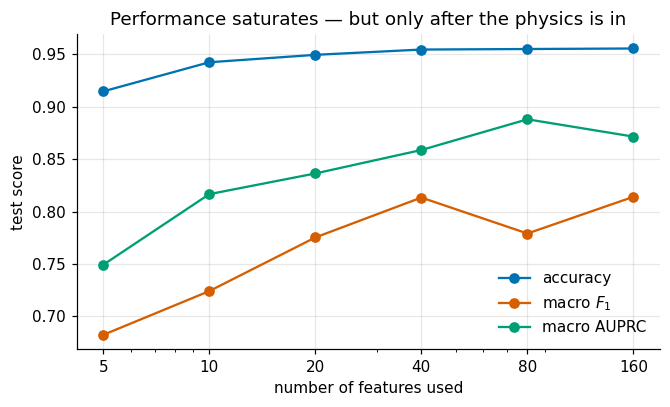

5 -> 160 features:  accuracy 0.915 -> 0.956   macro F1 0.682 -> 0.814


In [4]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
for col, lab, colr in [("accuracy", "accuracy", "#0072B2"),
                       ("macro_f1", "macro $F_1$", "#D55E00"),
                       ("macro_auprc", "macro AUPRC", "#009E73")]:
    ax.plot(curve.k, curve[col], "o-", color=colr, label=lab)
ax.set_xscale("log"); ax.set_xticks(ks); ax.set_xticklabels(ks)
ax.set_xlabel("number of features used"); ax.set_ylabel("test score")
ax.set_title("Performance saturates — but only after the physics is in")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"5 -> 160 features:  accuracy {curve.accuracy.iloc[0]:.3f} -> "
      f"{curve.accuracy.iloc[-1]:.3f}   macro F1 {curve.macro_f1.iloc[0]:.3f} -> "
      f"{curve.macro_f1.iloc[-1]:.3f}")

Three things to notice.

**The curve rises steeply and then flattens.** Most of the performance arrives in
the first few dozen features, and the last eighty buy very little. That is what a
*sufficient* representation looks like: once the physics is described, adding
more description does nothing.

**The gain from bad representation to good is large** — several points of
accuracy and more than ten of macro $F_1$ between five features and the full set.
Keep that magnitude in mind when you read §3.

**The macro $F_1$ curve wobbles rather than rising smoothly.** That is not a bug
and it is worth understanding: macro $F_1$ averages over classes, so it is
dominated by the rare ones, and this test split contains only nine TDEs. A single
object changing its label moves the curve visibly. Accuracy and AUPRC, which lean
on the well-populated classes, are much steadier. This is your first warning that
**rare-class numbers from one split are noise** — a theme we return to at the end.

Look at the top of the ranking to see which ones the model actually leans on.

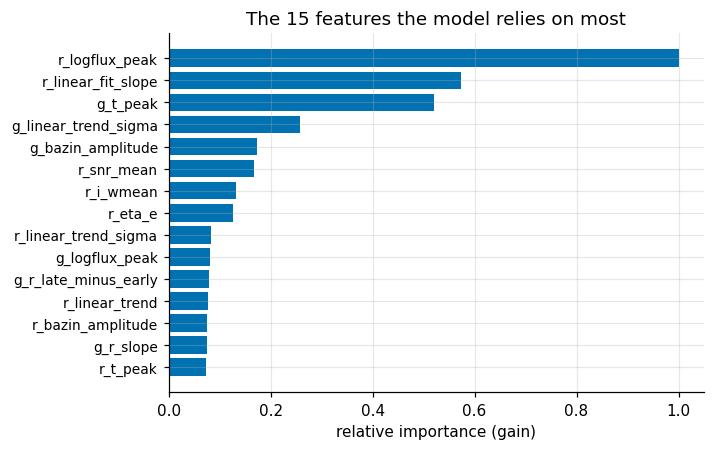

In [5]:
top = gain.head(15)[::-1]
fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.barh(range(len(top)), top.values / top.values.max(), color="#0072B2")
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=9)
ax.set_xlabel("relative importance (gain)")
ax.set_title("The 15 features the model relies on most")
plt.tight_layout(); plt.show()

---
## 3. The model family matters far less than the features

If the features really are doing the work, then *what consumes them* should
matter much less than people assume. Let's test that directly: hand the identical
160 features to four completely different learners.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

Xtr = X_train.to_numpy(); Xte = X_test.to_numpy()

def sk(model):
    return make_pipeline(SimpleImputer(strategy="median"),
                         StandardScaler(), model)

learners = {
    "logistic regression": sk(LogisticRegression(max_iter=2000, C=1.0)),
    "random forest":       sk(RandomForestClassifier(n_estimators=400,
                                                     min_samples_leaf=2,
                                                     random_state=RNG, n_jobs=-1)),
    "neural network (MLP)": sk(MLPClassifier(hidden_layer_sizes=(256, 128),
                                             max_iter=400, random_state=RNG,
                                             early_stopping=True)),
}

rows = []
for name, mdl in learners.items():
    t0 = time.time(); mdl.fit(Xtr, y_train)
    p = mdl.predict_proba(Xte)
    m = compute_metrics(y_test, p)
    rows.append({"model": name, "accuracy": m["accuracy"],
                 "macro F1": m["macro_f1"], "macro AUPRC": m["macro_auprc"],
                 "ECE": m["ece"], "fit (s)": time.time() - t0})
    print(f"  {name:22s} done in {time.time()-t0:5.1f}s")

t0 = time.time()
p_lgb = full.predict(X_test, num_iteration=full.best_iteration)
m = compute_metrics(y_test, p_lgb)
rows.append({"model": "gradient boosting (FLARE)", "accuracy": m["accuracy"],
             "macro F1": m["macro_f1"], "macro AUPRC": m["macro_auprc"],
             "ECE": m["ece"], "fit (s)": np.nan})
comp = pd.DataFrame(rows).set_index("model")
print()
print(comp.round(4).to_string())

  logistic regression    done in   0.5s


  random forest          done in   3.5s


  neural network (MLP)   done in   3.1s

                           accuracy  macro F1  macro AUPRC     ECE  fit (s)
model                                                                      
logistic regression          0.9308    0.7410       0.7894  0.0184   0.4821
random forest                0.9495    0.7329       0.8746  0.0761   3.4639
neural network (MLP)         0.9328    0.7155       0.8364  0.0128   3.0513
gradient boosting (FLARE)    0.9555    0.7823       0.8495  0.0114      NaN


Look at the **accuracy** column: four learners with completely different
inductive biases — a linear model, a bagged forest, a neural network, and a
boosted ensemble — land within about two percentage points of each other. Compare
that with §2, where changing the *representation* moved accuracy by four points
and macro $F_1$ by more than ten.

That ratio is the point. **Once the representation is right, the choice of
classifier is a second-order decision.** It is also why FLARE does not use a deep
sequence model: a deep model's job is to *learn* the representation, and here the
representation is already known and cheap to compute.

Second-order is not zero-order, though. Boosting does come out ahead, and the
margin is larger on macro $F_1$ than on accuracy — the rare classes are where a
stronger learner still earns its keep.

Now look at the **ECE** column, the calibration error. Here the models are *not*
interchangeable: the spread is several-fold, and it does not track accuracy at
all. The random forest is the most accurate of the three scikit-learn models and
the worst calibrated of all four. Accuracy alone would never have told you that.
The next section explains why.

---
## 4. The features are readable physics

A representation you designed is a representation you can interrogate. Ask the
model why it calls something a TDE, and the answer is a sentence about astronomy
rather than a heat-map over a hidden layer.

In [7]:
import shap

expl = shap.TreeExplainer(full)
sub = X_test.sample(min(600, len(X_test)), random_state=RNG)
sv = expl.shap_values(sub)
sv = np.stack(sv, axis=-1) if isinstance(sv, list) else sv   # (n, feat, class)

tde_idx = BROAD_CLASSES.index("TDE")
tde_shap = pd.Series(np.abs(sv[:, :, tde_idx]).mean(axis=0),
                     index=sub.columns).sort_values(ascending=False)
print("What drives the TDE decision:\n")
for name, val in tde_shap.head(8).items():
    print(f"  {name:28s} {val:.4f}")

What drives the TDE decision:

  g_r_mean                     0.1610
  g_eta_e                      0.1087
  g_r_wmean                    0.0925
  g_r_late                     0.0850
  g_r_slope                    0.0811
  r_eta_e                      0.0766
  g_linear_trend_sigma         0.0491
  i_gap_max                    0.0422


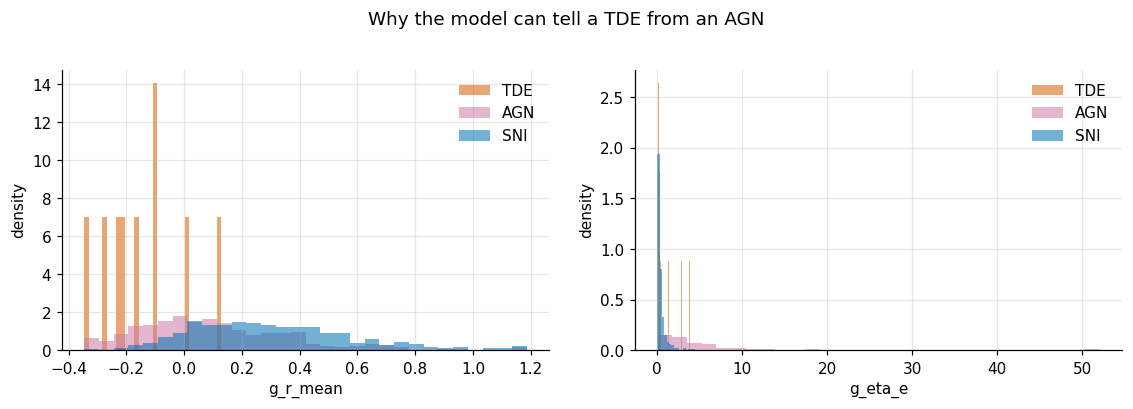

In [8]:
# the two features that matter most, TDE against its main confusers
feats = [f for f in tde_shap.head(12).index if sub[f].notna().mean() > 0.6][:2]
fig, axes = plt.subplots(1, len(feats), figsize=(5.2 * len(feats), 3.6))
axes = np.atleast_1d(axes)
for ax, f in zip(axes, feats):
    for cls in ["TDE", "AGN", "SNI"]:
        v = X_test[f][y_test == BROAD_CLASSES.index(cls)].dropna()
        if len(v) > 3:
            lo, hi = np.nanpercentile(X_test[f].dropna(), [1, 99])
            ax.hist(np.clip(v, lo, hi), bins=30, density=True, alpha=0.55,
                    color=CLASS_COLOR[cls], label=cls)
    ax.set_xlabel(f); ax.set_ylabel("density"); ax.legend(frameon=False)
plt.suptitle("Why the model can tell a TDE from an AGN", y=1.02)
plt.tight_layout(); plt.show()

The features at the top of that list are colour and colour-evolution terms, and
the histograms show why. **Tidal disruption events are blue and they stay blue**
— the accretion disc holds a roughly constant temperature for months. Supernovae
start blue and redden as they expand and cool. AGN vary stochastically without a
coherent colour trend.

That is textbook transient physics, recovered by the model from data. And it is
*auditable*: an astronomer can look at this and agree or disagree, which is a
different relationship with a model than trusting it.

---
## 5. Honest probabilities

A classifier that says "90% confident" should be right 90% of the time it says
that. Astonishingly many are not — and it matters, because in a real survey the
probability is what decides whether a telescope slews.

Plot predicted confidence against observed accuracy. The diagonal is perfection.

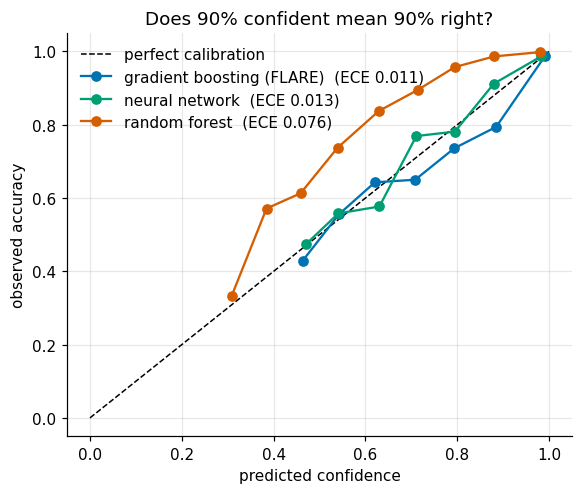

In [9]:
def reliability(y, p, n_bins=12):
    conf, pred = p.max(1), p.argmax(1)
    correct = (pred == y).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    xs, ys, ns = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 8:
            xs.append(conf[m].mean()); ys.append(correct[m].mean()); ns.append(m.sum())
    return np.array(xs), np.array(ys), np.array(ns)

p_mlp = learners["neural network (MLP)"].predict_proba(Xte)
p_rf  = learners["random forest"].predict_proba(Xte)

fig, ax = plt.subplots(figsize=(5.4, 4.6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
for p, lab, colr in [(p_lgb, "gradient boosting (FLARE)", "#0072B2"),
                     (p_mlp, "neural network", "#009E73"),
                     (p_rf,  "random forest", "#D55E00")]:
    xs, ys, _ = reliability(y_test, p)
    ax.plot(xs, ys, "o-", color=colr,
            label=f"{lab}  (ECE {ece(y_test, p):.3f})")
ax.set_xlabel("predicted confidence"); ax.set_ylabel("observed accuracy")
ax.set_title("Does 90% confident mean 90% right?")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

The boosted model tracks the diagonal closely. So, largely, does the neural
network. The **random forest sits well below the diagonal** at high confidence:
when it says 95% it is right rather less often than that. It is overconfident,
and it is the most accurate of the three scikit-learn models — accuracy and
honesty are simply different properties.

The mechanism is not mysterious, and it is worth stating precisely because the
common folklore ("neural networks are overconfident, trees are not") is not what
this experiment shows.

**What matters is how the model is fitted, not whether it is a net or a tree.**
Boosting here stops the moment held-out log-loss stops improving, so it never
gets to sharpen its probabilities toward 0 and 1. The MLP is configured the same
way (`early_stopping=True`) and inherits the same protection — which is why it is
also well calibrated. The random forest has no such mechanism: its probability is
the fraction of trees voting for a class, and with 400 deep trees that fraction
saturates near 1 for anything remotely easy.

Calibration therefore is not a post-processing step bolted on at the end. It
falls out of the fitting procedure, and you get it by **optimising a proper
scoring rule on held-out data and stopping when it stops improving**. That is one
of the reasons FLARE's classifier is an early-stopped boosted ensemble — and it
is a property you must *measure*, per model, rather than assume from its family.

---
## 6. Uncertainty you can actually promise

Good calibration is not the same as a guarantee. The usual way to be careful is a
confidence threshold: "only act when the model is more than 90% sure." It sounds
safe. Let's measure what it actually does per class.

The alternative is **conformal prediction**, which returns a *set* of classes
instead of one label, and comes with a coverage guarantee: the true class is in
the set at least 90% of the time. Calibrated per class (a *Mondrian* conformal
predictor), that promise holds for rare classes too.

In [10]:
from flare import conformal

p_val = full.predict(X_val, num_iteration=full.best_iteration)
alpha = 0.10
qhat = conformal.calibrate(p_val, y_val, alpha=alpha)
sets = conformal.prediction_sets(p_lgb, qhat)

THRESH = 0.90
conf, pred = p_lgb.max(1), p_lgb.argmax(1)
rows = []
for i, cls in enumerate(BROAD_CLASSES):
    m = y_test == i
    if m.sum() == 0:
        continue
    kept = conf[m] >= THRESH
    rows.append({
        "class": cls, "n": int(m.sum()),
        "threshold: kept": f"{kept.mean():.0%}",
        "threshold: correct among kept":
            f"{(pred[m][kept] == i).mean():.0%}" if kept.sum() else "—",
        "conformal: coverage": f"{sets[m, i].mean():.0%}",
        "conformal: avg set size": f"{sets[m].sum(1).mean():.2f}",
    })
print(f"Confidence threshold = {THRESH:.0%};  conformal target = {1-alpha:.0%}\n")
print(pd.DataFrame(rows).set_index("class").to_string())

Confidence threshold = 90%;  conformal target = 90%

         n threshold: kept threshold: correct among kept conformal: coverage conformal: avg set size
class                                                                                               
SNI    886             93%                          100%                 91%                    0.99
SNII   219             70%                           90%                 93%                    1.05
CV      91             76%                           97%                 86%                    1.05
AGN    774             95%                          100%                 92%                    0.98
TDE      9             44%                            0%                 78%                    1.44


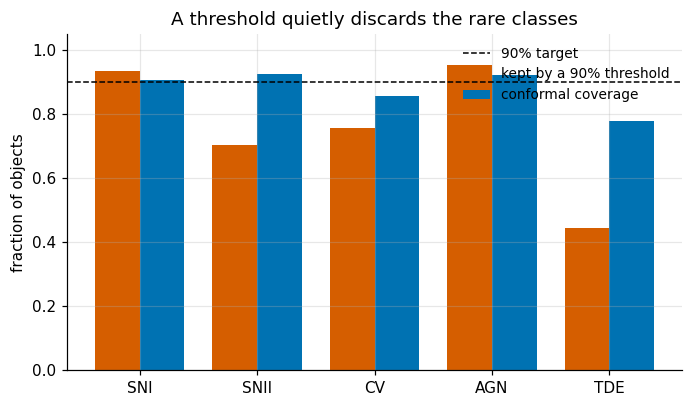

In [11]:
cov = [sets[y_test == i, i].mean() for i in range(5) if (y_test == i).sum()]
kept = [(conf[y_test == i] >= THRESH).mean() for i in range(5) if (y_test == i).sum()]
labs = [c for i, c in enumerate(BROAD_CLASSES) if (y_test == i).sum()]

x = np.arange(len(labs)); w = 0.38
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.bar(x - w/2, kept, w, label=f"kept by a {THRESH:.0%} threshold", color="#D55E00")
ax.bar(x + w/2, cov, w, label="conformal coverage", color="#0072B2")
ax.axhline(1 - alpha, ls="--", c="k", lw=1, label=f"{1-alpha:.0%} target")
ax.set_xticks(x); ax.set_xticklabels(labs); ax.set_ylim(0, 1.05)
ax.set_ylabel("fraction of objects")
ax.set_title("A threshold quietly discards the rare classes")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

The confidence threshold is not neutral. It keeps almost every easy object and
throws away a large share of the rare, interesting ones — precisely the objects
you built the classifier to find. Worse, it does this *silently*: your reported
accuracy goes up, because you deleted the hard cases. Look at the TDE row and
what survives the cut.

Conformal prediction makes the opposite trade. Nothing is discarded. When the
model is unsure it returns two or three candidate classes instead of one, and the
average set size tells you honestly how often that happens — barely above one for
the easy classes, larger for TDEs. A shortlist of two classes you can trust is
far more useful to a follow-up programme than a single label you cannot.

**And now the honest caveat, which is itself the lesson.** Look at the TDE
coverage: it falls short of the 90% target. That is not a bug in conformal
prediction — it is conformal prediction telling the truth about your data. The
per-class guarantee is a *finite-sample* one, and it is calibrated here on nine
TDEs. With $n$ calibration objects the achievable level steps in units of roughly
$1/(n{+}1)$, so with $n = 9$ you simply cannot tune coverage finely, and the
realised value scatters widely around the target.

The fix is more calibration data, not a different method: evaluated with
cross-validation over the full 13,153-object sample, where 65 TDEs are available
for calibration, per-class coverage does reach the target. The rule to take away
is that **a guarantee conditioned on a class you have nine examples of is a weak
guarantee**, and a method that lets you see this is better than one that hides
it.

---
## 7. One knob for the rare-class trade-off

You will always be asked: *can it find more TDEs?* Yes — and the cost is
explicit. Weight the training examples by $(1/n_c)^\beta$, where $n_c$ is the
size of class $c$. $\beta = 0$ ignores imbalance; larger $\beta$ pushes the model
toward the rare classes.

In [12]:
def weights(y, beta):
    counts = np.bincount(y, minlength=5).astype(float)
    return ((len(y) / (5 * counts)) ** beta)[y]

betas, knob = [0.0, 0.5, 0.9, 1.25, 1.75], []
for b in betas:
    m = fit(X_train, y_train, X_val, y_val, weight=weights(y_train, b))
    met = compute_metrics(y_test, m.predict(X_test, num_iteration=m.best_iteration))
    knob.append({"beta": b, "accuracy": met["accuracy"],
                 "balanced acc": met["balanced_accuracy"],
                 "macro F1": met["macro_f1"], "TDE recall": met["recall_TDE"]})
    print(f"  beta={b:4.2f}  acc={met['accuracy']:.4f}  "
          f"balacc={met['balanced_accuracy']:.4f}  TDE recall={met['recall_TDE']:.3f}")
knob = pd.DataFrame(knob)

  beta=0.00  acc=0.9555  balacc=0.7479  TDE recall=0.111


  beta=0.50  acc=0.9550  balacc=0.7776  TDE recall=0.222


  beta=0.90  acc=0.9535  balacc=0.7957  TDE recall=0.333


  beta=1.25  acc=0.9565  balacc=0.8522  TDE recall=0.556


  beta=1.75  acc=0.9515  balacc=0.8484  TDE recall=0.556


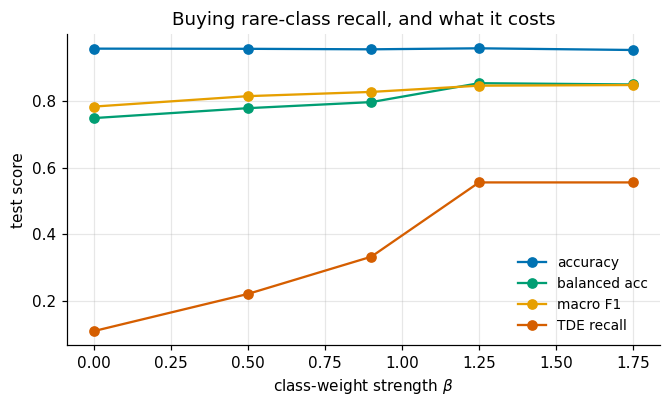

In [13]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
for col, colr in [("accuracy", "#0072B2"), ("balanced acc", "#009E73"),
                  ("macro F1", "#E69F00"), ("TDE recall", "#D55E00")]:
    ax.plot(knob.beta, knob[col], "o-", color=colr, label=col)
ax.set_xlabel(r"class-weight strength $\beta$"); ax.set_ylabel("test score")
ax.set_title("Buying rare-class recall, and what it costs")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

Read the curves carefully, because the result is more interesting than the usual
slogan.

Balanced accuracy and TDE recall climb substantially with $\beta$. Overall
accuracy, meanwhile, barely moves — it stays within a few tenths of a percentage
point across the whole range. On this split the trade-off is close to *free*.

Why? Because accuracy is dominated by SNI and AGN, which together are most of the
sample. Reweighting moves a modest number of borderline objects out of those
classes and into the rare ones. You lose a little where you have thousands and
gain a lot where you have tens, and accuracy — being an average over objects,
not classes — hardly notices.

Two lessons follow. First, **when your classes are this imbalanced, accuracy is
close to useless as a model-selection criterion**; it is nearly constant across
models you should care a great deal about choosing between. Second, the cost of
class weighting is real but it shows up in *other* metrics — macro $F_1$ and
precision on the rare classes — so those are what you must watch.

Which point you want is a *scientific* decision, not a machine-learning one. A
survey broker hunting TDEs and a population-statistics study want different ends
of this curve, so FLARE ships two operating points rather than pretending one is
universally correct: a balanced default, and a class-weighted variant for
rare-transient work.

---
## 8. What transfers to your own problem

Nothing here is specific to ZTF. The reasoning generalises:

1. **Count your rare class before choosing a method.** Tens of examples means
   features; tens of thousands means representation learning. This one number
   should drive the decision more than fashion does.
2. **Spend your effort on the representation.** §2 and §3 together: moving along
   the feature axis changed the score far more than swapping the learner.
3. **Prefer a model you can question.** When the answer is "blue, and staying
   blue", a domain expert can check it. That is worth real accuracy.
4. **Never report accuracy alone.** §3 had four models with near-identical
   accuracy and several-fold differences in calibration; §7 had a knob that
   transformed rare-class recall while barely touching accuracy. Under strong
   imbalance, accuracy is nearly blind. Report balanced accuracy, macro $F_1$,
   AUPRC and ECE, and show a reliability diagram.
5. **Measure calibration, never assume it from the model family.** The folklore
   about nets and trees did not survive contact with §5.
6. **Do not threshold on confidence — it deletes your rare classes.** Use
   prediction sets, and check that the realised coverage matches the target
   *per class*.
7. **Make the imbalance trade-off explicit** and hand the choice to the scientist.

And the honest caveat: the numbers in this notebook come from a single
train/validation/test split, so small differences here are noise. Published FLARE
results use repeated five-fold cross-validation over 13,153 objects with bootstrap
confidence intervals. If you take one methodological habit away, take that one.

---
## 9. Everything you just saw is on GitHub

The whole package — features, model, conformal layer, pretrained weights, and
this notebook — is one repository:

### https://github.com/applecider-ml/flare

```bash
git clone https://github.com/applecider-ml/flare.git
cd flare
pip install -e .
```

**Classify objects with the pretrained model** (no training, no GPU):

```python
from flare import FlareClassifier

clf   = FlareClassifier.from_pretrained()
proba = clf.predict_proba_from_files(["ZTF20xxxxxxx.npz"])   # (N, 5)
label = clf.predict_from_files(["ZTF20xxxxxxx.npz"])         # ['TDE']
sets  = clf.prediction_sets_from_files(["ZTF20xxxxxxx.npz"]) # [['TDE','AGN']]
```

From the command line:

```bash
python scripts/predict.py --npz-dir path/to/objects --out predictions.csv
```

**Retrain it from scratch** — minutes on a laptop, no GPU required:

```bash
export FLARE_DATA=/path/to/photo_events
python scripts/train.py            # feature extraction + Optuna + conformal
python scripts/evaluate.py         # bootstrap CIs and coverage
```

**Rerun this notebook**:

```bash
export FLARE_DATA=/path/to/photo_events
jupyter lab notebooks/why_flare_works.ipynb
```

Other notebooks in the repository:

| Notebook | What it is |
|---|---|
| `flare_tutorial.ipynb` | hands-on introduction: light curves → features → trees → conformal |
| `ztf_summer_school/build_your_own_flare.ipynb` | build the classifier from zero, the ML fundamentals |
| `ztf_summer_school/tutorial.ipynb` | classification **and** anomaly detection: finding what you were never taught to find |
| `ztf_summer_school/beyond_the_catalog.ipynb` | real out-of-taxonomy transients pushed through the model |

Questions, issues and pull requests are welcome.